# MoPR Annotation → COG + GPKG Pipeline

Converts the tiled PNG annotations in `training/annotations/` into:
- A georeferenced GeoTIFF mosaic (Cloud-Optimized GeoTIFF / COG)
- A GeoPackage (GPKG) with per-class polygon vectors

**This same pipeline is used later to convert AI model outputs to GPKG.**  
Only `ANNOTATION_DIR` needs to point at the model prediction folder.

### Class mapping (annotation pixel values)
| Value | Class |
|-------|-------|
| 0 | background (skipped) |
| 1 | road |
| 2 | bridge |
| 3 | waterbody |
| 4 | utility_poly |
| 5 | Built_Up_Area |
| 255 | no-data / ignore (skipped) |

## Cell 1 – Install dependencies

In [5]:
!pip install -q rasterio rio-cogeo shapely geopandas tqdm
# Verify
import rasterio, shapely, geopandas
print('rasterio', rasterio.__version__)
print('geopandas', geopandas.__version__)
print('shapely', shapely.__version__)

rasterio 1.5.0
geopandas 1.1.3
shapely 2.1.2


## Cell 2A – Mount Google Drive and set paths (Option 1: Processing directly from Google Drive)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── EDIT THESE to match your Drive folder layout ──────────────────────────────
# Example: you uploaded the hackathon data to
# My Drive / MoPR_Hackathon / Training / 1. Tiles /
DRIVE_BASE   = Path('/content/drive/MyDrive/mopr-hackathon/gpkg_pipeline')
TILES_ROOT   = DRIVE_BASE / 'training'
OUTPUT_DIR   = DRIVE_BASE / 'output'
# ──────────────────────────────────────────────────────────────────────────────

ANNOTATION_DIR = TILES_ROOT / 'annotations'
IMAGES_DIR     = TILES_ROOT / 'images'
GEOREF_DIR     = OUTPUT_DIR / 'georef_tiles'
MOSAIC_PATH    = OUTPUT_DIR / 'annotation_mosaic.tif'
COG_PATH       = OUTPUT_DIR / 'annotation_mosaic_cog.tif'
GPKG_PATH      = OUTPUT_DIR / 'annotation_vectors.gpkg'

# Sanity check
assert ANNOTATION_DIR.exists(), f'annotations dir not found: {ANNOTATION_DIR}'
assert IMAGES_DIR.exists(),     f'images dir not found: {IMAGES_DIR}'
print('Paths OK')
print(f'  annotations: {len(list(ANNOTATION_DIR.glob("*.png")))} PNGs')
print(f'  images:      {len(list(IMAGES_DIR.glob("*.tif")))} TIFs')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths OK
  annotations: 892 PNGs
  images:      892 TIFs


## Cell 2B – Mount Google Drive and set paths (Option 2: Transferring to local drive for faster processing)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import shutil

# ── EDIT THESE to match your Drive folder layout ──────────────────────────────
# Example: you uploaded the hackathon data to
# My Drive / MoPR_Hackathon / Training / 1. Tiles /
DRIVE_BASE_ORIGINAL = Path('/content/drive/MyDrive/mopr-hackathon/gpkg_pipeline')

# Local paths for processing
LOCAL_DATA_DIR = Path('/content/mopr-data')
TILES_ROOT   = LOCAL_DATA_DIR / 'training'
OUTPUT_DIR   = LOCAL_DATA_DIR / 'output'

# Ensure local directories exist
TILES_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ──────────────────────────────────────────────────────────────────────────────

ANNOTATION_DIR = TILES_ROOT / 'annotations'
IMAGES_DIR     = TILES_ROOT / 'images'
GEOREF_DIR     = OUTPUT_DIR / 'georef_tiles'
MOSAIC_PATH    = OUTPUT_DIR / 'annotation_mosaic.tif'
COG_PATH       = OUTPUT_DIR / 'annotation_mosaic_cog.tif'
GPKG_PATH      = OUTPUT_DIR / 'annotation_vectors.gpkg'

# Sanity check (these checks will now run *after* data is copied locally)
# The initial check will be performed on the original Drive paths during copying
print('Paths configured for local processing.')

## Cell 2B.1 – Copy data from Drive to local storage

In [ ]:
print(f'Copying annotation tiles from {DRIVE_BASE_ORIGINAL / "training" / "annotations"} to {ANNOTATION_DIR}')
shutil.copytree(DRIVE_BASE_ORIGINAL / 'training' / 'annotations', ANNOTATION_DIR, dirs_exist_ok=True)

print(f'Copying image tiles from {DRIVE_BASE_ORIGINAL / "training" / "images"} to {IMAGES_DIR}')
shutil.copytree(DRIVE_BASE_ORIGINAL / 'training' / 'images', IMAGES_DIR, dirs_exist_ok=True)

# Also copy the pipeline script locally
script_path_drive = DRIVE_BASE_ORIGINAL / 'annotation_to_gpkg_pipeline.py'
script_path_local = LOCAL_DATA_DIR / 'annotation_to_gpkg_pipeline.py'
shutil.copy(script_path_drive, script_path_local)


# Sanity check on local data
assert ANNOTATION_DIR.exists(), f'annotations dir not found locally: {ANNOTATION_DIR}'
assert IMAGES_DIR.exists(),     f'images dir not found locally: {IMAGES_DIR}'
print('Local paths OK')
print(f'  annotations: {len(list(ANNOTATION_DIR.glob("*.png")))} PNGs')
print(f'  images:      {len(list(IMAGES_DIR.glob("*.tif")))} TIFs')

## Cell 3 – Import script

In [11]:
# Option A: clone from GitHub
# !git clone https://github.com/YOUR_USERNAME/mopr-hackathon.git /content/mopr-hackathon
# %cd /content/mopr-hackathon

import importlib.util

script_path = DRIVE_BASE / 'annotation_to_gpkg_pipeline.py'

spec = importlib.util.spec_from_file_location("annotation_to_gpkg_pipeline", script_path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

## Cell 4 – Run Step 1: Georeference all annotation tiles

In [12]:
# The 'module' object containing the loaded script is available from the previous cell.
# We need to assign its attributes to global names for direct use.
step1_georeference_tiles = module.step1_georeference_tiles
step2_mosaic_to_cog = module.step2_mosaic_to_cog
step2b_validate_cog = module.step2b_validate_cog
step3_polygonise_to_gpkg = module.step3_polygonise_to_gpkg
CLASS_MAP = module.CLASS_MAP
MIN_AREA_M2 = module.MIN_AREA_M2
DEFAULT_CONFIDENCE = module.DEFAULT_CONFIDENCE
QGIS_README = module.QGIS_README

step1_georeference_tiles(ANNOTATION_DIR, IMAGES_DIR, GEOREF_DIR)

[Step 1] Found 892 annotation tiles to georeference.


Georeferencing tiles: 100%|██████████| 892/892 [11:37<00:00,  1.28it/s]

[Step 1] Done. Georeferenced tiles written to: /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/georef_tiles


## Cell 5 – Run Step 2: Mosaic → COG

In [13]:
cog_path = step2_mosaic_to_cog(GEOREF_DIR, MOSAIC_PATH, COG_PATH)
step2b_validate_cog(Path(cog_path))

[Step 2] Merging 892 georeferenced tiles into mosaic…


Opening tiles: 100%|██████████| 892/892 [00:30<00:00, 29.53it/s]


[Step 2] Writing raw mosaic → /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/annotation_mosaic.tif


Reading input: /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/annotation_mosaic.tif



[Step 2] Converting to COG → /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/annotation_mosaic_cog.tif


Adding overviews...
Updating dataset tags...
Writing output to: /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/annotation_mosaic_cog.tif


[Step 2] Done. COG written to: /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/annotation_mosaic_cog.tif

[COG Validation] annotation_mosaic_cog.tif
  Valid  : True


True

## Cell 6 – Run Step 3: Polygonise → GPKG

In [14]:
gdf = step3_polygonise_to_gpkg(
    cog_path=Path(cog_path),
    gpkg_path=GPKG_PATH,
    class_map=CLASS_MAP,
    min_area_m2=MIN_AREA_M2,
    confidence=DEFAULT_CONFIDENCE,
)
gdf.head()


[Step 3] Polygonising classes from annotation_mosaic_cog.tif…


Polygonising classes:  20%|██        | 1/5 [00:37<02:31, 37.78s/it]

  Class   1 (road                ):     2 polygons  (total area = 20603.9 m²)


Polygonising classes:  40%|████      | 2/5 [00:40<00:51, 17.09s/it]

  Class 2 (bridge): no pixels found – skipping


...

  Class   4 (utility_poly        ):    26 polygons  (total area = 909.9 m²)


Polygonising classes: 100%|██████████| 5/5 [02:30<00:00, 30.15s/it]

  Class   5 (Built_Up_Area       ):   209 polygons  (total area = 20503.8 m²)

[Step 3] Writing 253 total polygons to GPKG…


[Step 3] Done. GPKG written to: /content/drive/MyDrive/mopr-hackathon/gpkg_pipeline/output/annotation_vectors.gpkg


,geometry,class_id,class_name,area_m2,confidence
0,"POLYGON ((524594.129 2102542.791, 524594.164 2...",1,road,5135.5944,1.0
1,"POLYGON ((526087.579 2102327.156, 526087.684 2...",1,road,15468.3543,1.0
2,"POLYGON ((524521.679 2102422.776, 524522.099 2...",3,waterbody,1013.0677,1.0
3,"POLYGON ((524713.094 2102319.666, 524713.304 2...",3,waterbody,117.1615,1.0
4,"POLYGON ((525084.654 2102342.696, 525084.689 2...",3,waterbody,703.9879,1.0


## Cell 7 – Quick inline preview (Colab map)

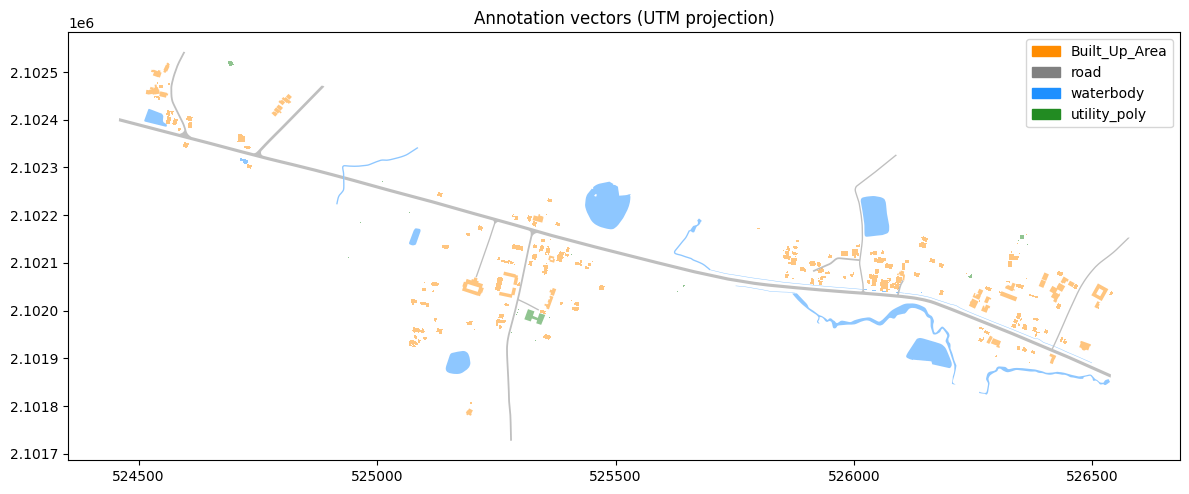

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colour_map = {'Built_Up_Area': '#FF8C00', 'road': '#808080', 'waterbody': '#1E90FF', 'utility_poly': '#228B22'}

fig, ax = plt.subplots(figsize=(12, 12))
for class_name, colour in colour_map.items():
    subset = gdf[gdf.class_name == class_name]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, alpha=0.5, label=class_name)

ax.set_title('Annotation vectors (UTM projection)')
patches = [mpatches.Patch(color=c, label=n) for n, c in colour_map.items()]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preview_map.png', dpi=150)
plt.show()

## Cell 8 – QGIS verification instructions

In [16]:
print(QGIS_README)


HOW TO VERIFY IN QGIS

1.  Open QGIS Desktop (3.x).

2.  Load the COG mosaic:
      Layer → Add Layer → Add Raster Layer → browse to annotation_mosaic_cog.tif
      In the layer Symbology, choose:
        Render type = Paletted/Unique values
        Classify → assign class colours:
          0   → transparent
          1   → orange     (building)
          3   → grey       (road)
          4   → blue       (waterbody)
          5   → green      (infrastructure)
          255 → transparent

3.  Load the GPKG vectors:
      Layer → Add Layer → Add Vector Layer → browse to annotation_vectors.gpkg
      Choose layer = segments
      Style by class_name field using Categorized renderer.

4.  Overlay with the original orthophoto tiles (drag any .tif from images/ folder).

5.  Visual QA checks:
      ✓  Building footprints align with visible structures
      ✓  Road polygons follow road corridors
      ✓  Water body polygons cover water surfaces
      ✓  No major misalignment between raster 

## Cell 9 – Backup processed data to Google Drive (if option 2B)

In [ ]:
import zipfile

# Define the target backup path in Google Drive
DRIVE_BACKUP_DIR = DRIVE_BASE_ORIGINAL / 'output_backup'
DRIVE_BACKUP_DIR.mkdir(parents=True, exist_ok=True)

# Create a timestamped zip file name
import datetime
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
backup_zip_name = f'mopr_output_backup_{timestamp}.zip'
backup_zip_path_local = OUTPUT_DIR / backup_zip_name
backup_zip_path_drive = DRIVE_BACKUP_DIR / backup_zip_name

print(f'Creating zip archive of local output directory: {backup_zip_path_local}')
with zipfile.ZipFile(backup_zip_path_local, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for entry in OUTPUT_DIR.iterdir():
        if entry.is_file():
            zipf.write(entry, arcname=entry.name)
        elif entry.is_dir():
            for root, _, files in os.walk(entry):
                for file in files:
                    file_path = Path(root) / file
                    zipf.write(file_path, arcname=file_path.relative_to(OUTPUT_DIR))

print(f'Copying backup zip to Google Drive: {backup_zip_path_drive}')
shutil.copy(backup_zip_path_local, backup_zip_path_drive)
print('Backup complete!')

---
## Swapping in AI model outputs

When your model produces prediction masks (one PNG per tile, same naming convention,
pixel values = class IDs), you only need to change **one path** and set the
confidence from model softmax scores:

```python
# Point at model predictions instead of ground-truth annotations
ANNOTATION_DIR = Path('/content/drive/MyDrive/MoPR_Hackathon/predictions')
COG_PATH       = OUTPUT_DIR / 'prediction_mosaic_cog.tif'
GPKG_PATH      = OUTPUT_DIR / 'prediction_vectors.gpkg'
DEFAULT_CONFIDENCE = 0.0   # will be overridden per-polygon from model scores

# Run the same steps 1–3
```

For per-polygon confidence from model logits, see `step3_polygonise_to_gpkg`
and replace `confidence=DEFAULT_CONFIDENCE` with a rasterio zonal-stats call
on the softmax probability map.